In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Shape: (267, 9)

Columns:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

Summary Statistics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


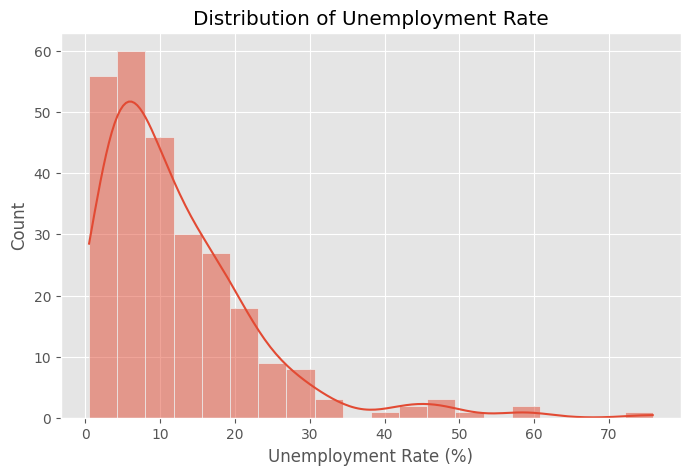

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.show()

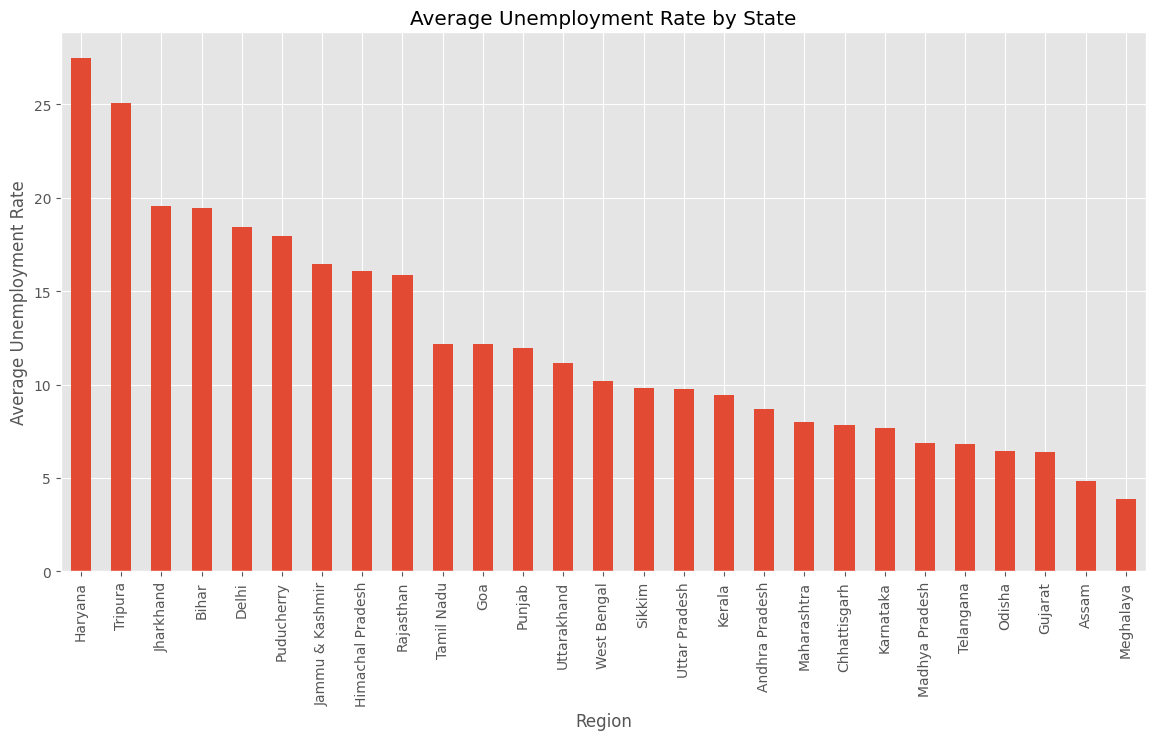

In [7]:
state = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

state = state.sort_values(ascending=False)

plt.figure(figsize=(14,7))

state.plot(kind="bar")

plt.ylabel("Average Unemployment Rate")

plt.title("Average Unemployment Rate by State")

plt.show()

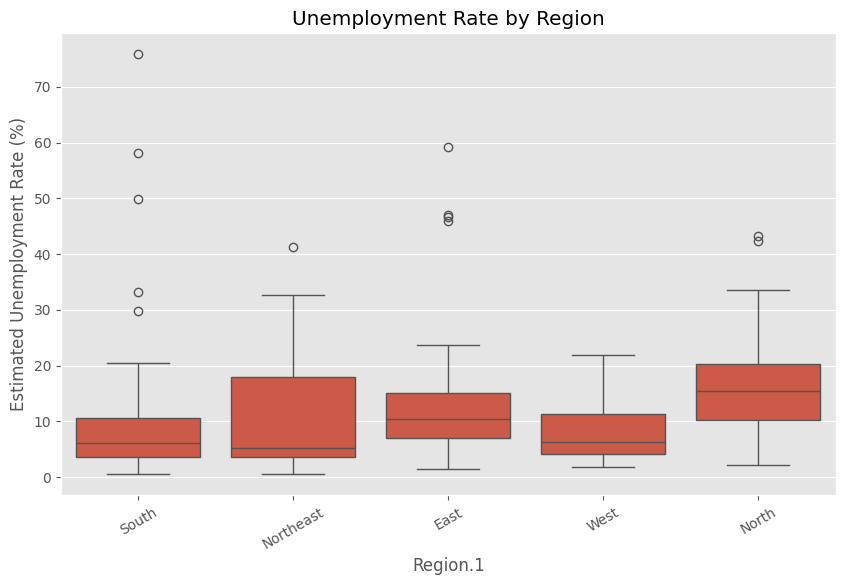

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Region.1",
    y="Estimated Unemployment Rate (%)"
)

plt.xticks(rotation=30)

plt.title("Unemployment Rate by Region")

plt.show()

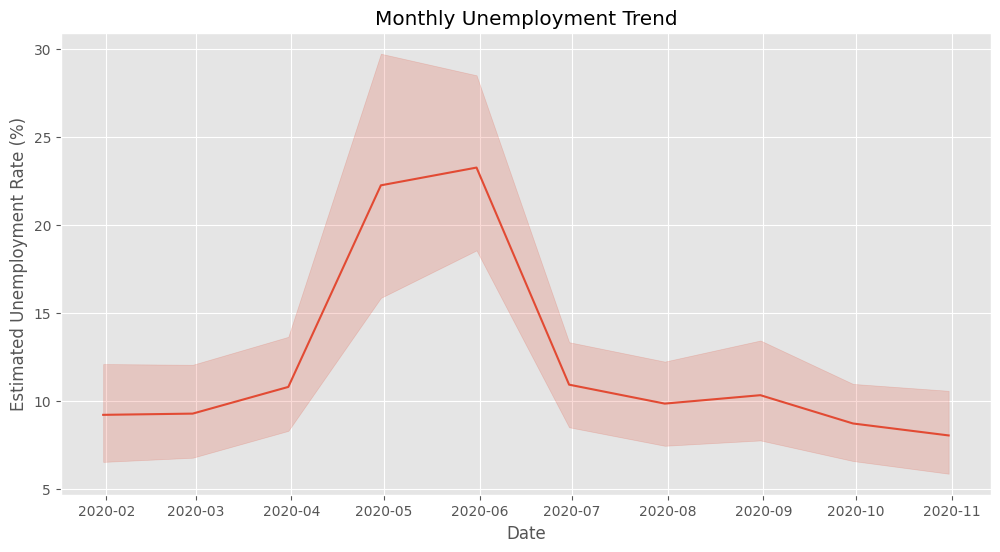

In [9]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Monthly Unemployment Trend")

plt.show()

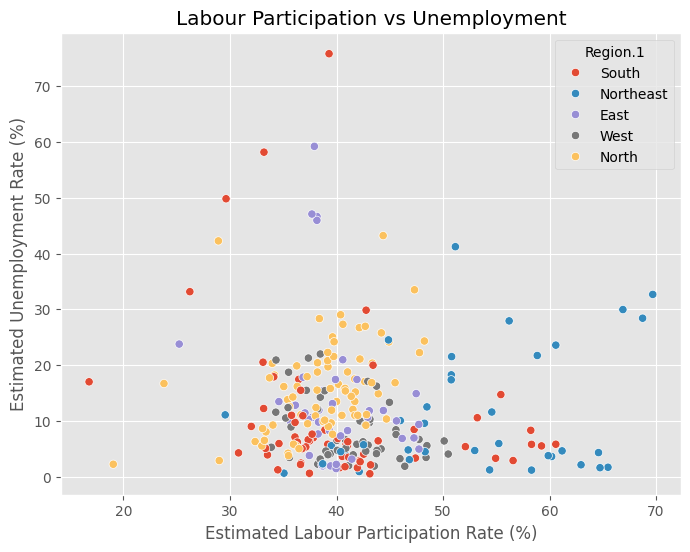

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)",
    hue="Region.1"
)

plt.title("Labour Participation vs Unemployment")

plt.show()

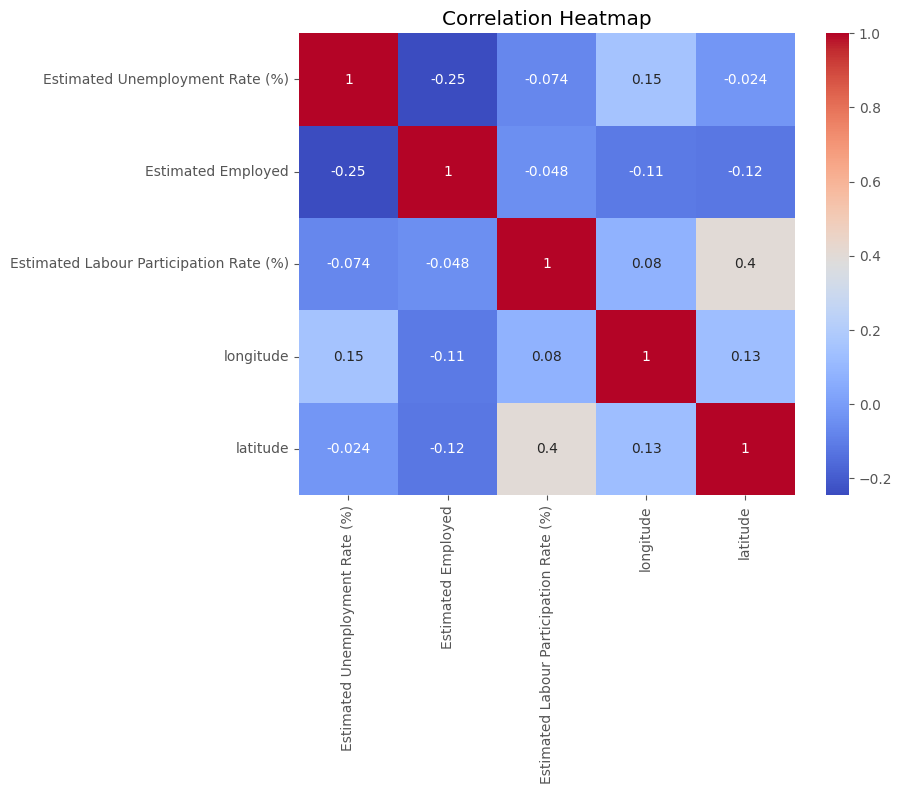

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
highest = df.loc[df["Estimated Unemployment Rate (%)"].idxmax()]

lowest = df.loc[df["Estimated Unemployment Rate (%)"].idxmin()]

print("Highest Unemployment\n")
print(highest)

print("\n\nLowest Unemployment\n")
print(lowest)

Highest Unemployment

Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                                    M
Estimated Unemployment Rate (%)                          75.85
Estimated Employed                                      117542
Estimated Labour Participation Rate (%)                   39.3
Region.1                                                 South
longitude                                              11.9416
latitude                                               79.8083
Name: 172, dtype: object


Lowest Unemployment

Region                                               Karnataka
Date                                       2020-08-31 00:00:00
Frequency                                                    M
Estimated Unemployment Rate (%)                            0.5
Estimated Employed                                    24094289
Estimated Labour Participation Rate (%)         

In [13]:
print("""
Conclusion

• The unemployment data was successfully analyzed using Python.

• Data visualization showed considerable variation in unemployment rates
  across different states and regions of India.

• The monthly trend indicates noticeable fluctuations during 2020,
  reflecting the impact of the COVID-19 pandemic.

• The project demonstrates the use of Pandas, Matplotlib, and Seaborn
  for exploratory data analysis (EDA) and visualization.
""")


Conclusion

• The unemployment data was successfully analyzed using Python.

• Data visualization showed considerable variation in unemployment rates
  across different states and regions of India.

• The monthly trend indicates noticeable fluctuations during 2020,
  reflecting the impact of the COVID-19 pandemic.

• The project demonstrates the use of Pandas, Matplotlib, and Seaborn
  for exploratory data analysis (EDA) and visualization.

